In [20]:
#4. Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. Embedding'leri 2 boyutta çizdir: 
#hangi harfler birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle karşılaştır. 
#libraries & data 
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

words = open('names.txt', 'r').read().splitlines()

In [21]:
#character mappings; i to s or vice versa
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [22]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
  
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append   
X = torch.tensor(X)
Y = torch.tensor(Y)

In [23]:
#data splitting again
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [24]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn(6,300,generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300, 27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [31]:
lossi=[]
stepi=[]
#training our model only with train set
for i in range(100000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,),generator=g)
  
  # forward pass
  emb = C[Xtr[ix]] 
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Ytr[ix])

  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.05
  for p in parameters:
    p.data += -lr * p.grad
    
      
stepi.append(i)
lossi.append(loss.item())

In [33]:
#reporting devs loss now with bigger net previous dev loss was 2.3654894828796387 
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
print(f'dev loss= {loss}')

dev loss= 2.236921787261963


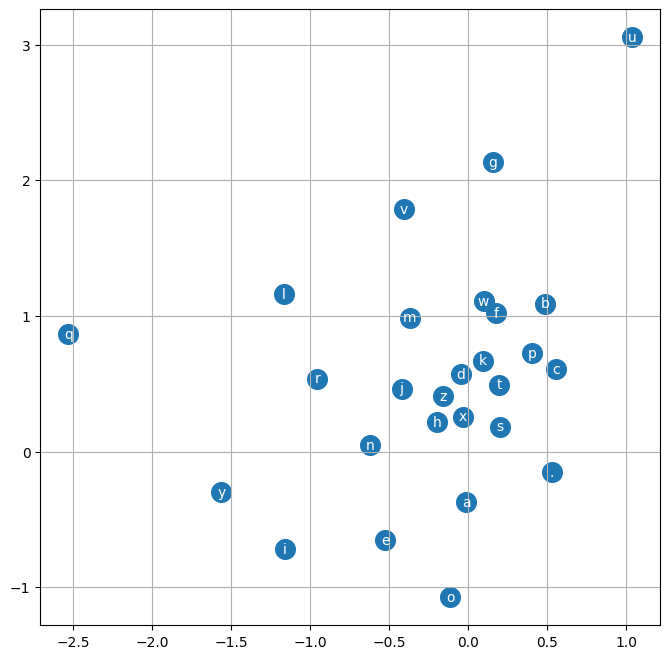

In [34]:
#visualize embeddings while we can :D
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [58]:
#scaling up embeddings as well from 2 to 10
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn(30,300,generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300, 27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [59]:
lossi=[]
stepi=[]

In [60]:
#training our model only with train set
for i in range(500000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,),generator=g)
  
  # forward pass
  emb = C[Xtr[ix]] 
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Ytr[ix])

  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad
    
      
  stepi.append(i)
  lossi.append(loss.log10().item())

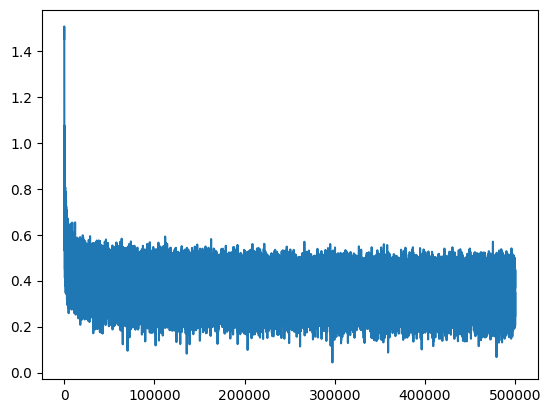

In [61]:
plt.plot(stepi,lossi)

In [62]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
print(f'dev loss= {loss}')

dev loss= 2.3468613624572754


In [63]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
print(f'training loss= {loss}')

training loss= 2.2420244216918945


In [66]:
# sampling from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(5):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

gen.
amarghanikaleigh.
harlini.
janainy.
kaykleigh.


In [69]:
##samples from biagram model
# cexze.
# momasurailezitynn.
# konimittain.
# llayn.
# ka.

#bigram loss     2.4543
#MLP dev loss   2.3469